In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import copy
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, normalize
import scipy.cluster.hierarchy as shc
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from tqdm import tqdm
from tensorboardX import SummaryWriter

%matplotlib inline

# define data

### FA data test

In [13]:
df_fa_test = pd.read_csv('data/test_factor_loadings_5.csv').iloc[:,1:]

### tSNE data

/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is de

<AxesSubplot: >

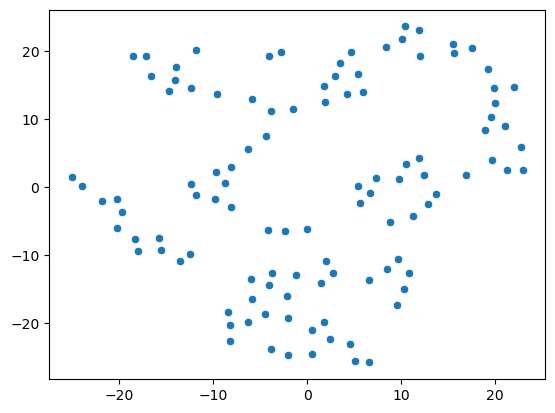

In [14]:
tsne_norm = TSNE(n_components=2, learning_rate='auto',init='random', perplexity=10)
tsne_normalized_data = tsne_norm.fit_transform(df_fa_test.iloc[:,2:])
sns.scatterplot(x=tsne_normalized_data[:,0], y=tsne_normalized_data[:,1])

### PCA data

/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:767: FutureWarning: is_sparse is deprec

<AxesSubplot: >

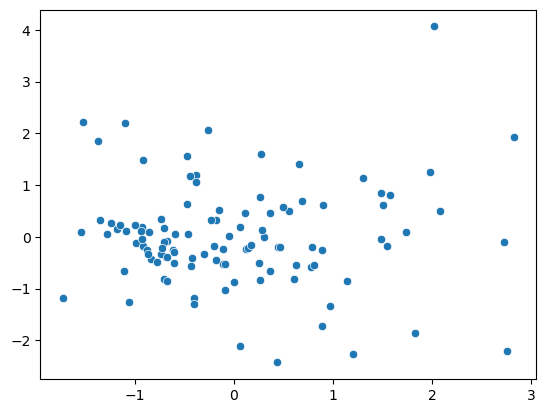

In [15]:
pca_norm = PCA(n_components=2)
pca_norm.fit(df_fa_test.iloc[:,2:])
pca_normalized_data = pca_norm.transform(X=df_fa_test.iloc[:,2:])
sns.scatterplot(x=pca_normalized_data[:,0], y=pca_normalized_data[:,1])

# BIC results

In [27]:
gmm_n_components = range(1, 10)
gmm_covariance = ["spherical", "tied", "diag", "full"]
results = {'gmm_n_components':[], 'gmm_covariance':[], 'test_score':[]}
X = df_fa_test
for gmm_n in tqdm(gmm_n_components):
    for c_type in gmm_covariance:
        gmm=GaussianMixture(n_components=gmm_n, covariance_type=c_type, n_init=2000).fit(X) 
        test_score = gmm.bic(X)
        results['gmm_n_components'].append(gmm_n)
        results['gmm_covariance'].append(c_type)
        results['test_score'].append(test_score)

df_result = pd.DataFrame(results)
# df_result = pd.DataFrame(results)[["pca_n_components", "gmm_n_components", "gmm_covariance", "test_score"]]            

  0%|                                                                                             | 0/9 [00:00<?, ?it/s]/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
/Users/matin/mi

/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:767: FutureWarning: is_sparse is deprec

/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:767: FutureWarning: is_sparse is deprec

/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
 44%|█████████████████████████████████████▊                                               | 4/9 [01:02<01:28, 17.79s/it]/Users/matin/mi

/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:767: FutureWarning: is_sparse is deprec

/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:767: FutureWarning: is_sparse is deprec

/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:767: FutureWarning: is_sparse is deprec

/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
100%|█████████████████████████████████████████████████████████████████████████████████████| 9/9 [04:49<00:00, 32.22s/it]


In [28]:
df_result.sort_values(by='test_score')

,gmm_n_components,gmm_covariance,test_score
35,9,full,1386.411666
31,8,full,1391.845891
15,4,full,1393.860439
23,6,full,1398.622862
11,3,full,1398.845054
27,7,full,1427.627738
20,6,spherical,1435.171975
24,7,spherical,1435.247785
8,3,spherical,1438.654374
12,4,spherical,1449.811410


In [50]:
df_result[(df_result['gmm_covariance']=='spherical') & (df_result['pca_n_components']==59)].sort_values(by='test_score')

,pca_n_components,gmm_n_components,gmm_covariance,test_score
1388,59,6,spherical,-34279.819287
1384,59,5,spherical,-34172.458371
1380,59,4,spherical,-33832.276453
1376,59,3,spherical,-32981.447373
1372,59,2,spherical,-32087.205831
1368,59,1,spherical,-28632.842451


# PCA results BIC Fivash

In [62]:
df_fa_test_fivash.shape

(108, 5)

In [64]:
pca_n_components = range(2, 4)
gmm_n_components = range(1, 7)
gmm_covariance = ["spherical", "tied", "diag", "full"]
results = {'pca_n_components':[], 'gmm_n_components':[], 'gmm_covariance':[], 'test_score':[]}
X = df_fa_test_fivash.iloc[:,2:]
for pca_n in pca_n_components:
    for gmm_n in gmm_n_components:
        for c_type in gmm_covariance:
            pca = PCA(n_components=pca_n)
            pca.fit(X)
            x_pca = pca.transform(X)
            gmm=GaussianMixture(n_components=gmm_n, covariance_type=c_type).fit(x_pca) 
            test_score = gmm.bic(x_pca)
            results['pca_n_components'].append(pca_n)
            results['gmm_n_components'].append(gmm_n)
            results['gmm_covariance'].append(c_type)
            results['test_score'].append(test_score)

            
df_result = pd.DataFrame(results)[["pca_n_components", "gmm_n_components", "gmm_covariance", "test_score"]]            

In [73]:
df_result

,pca_n_components,gmm_n_components,gmm_covariance,test_score
0,2,1,spherical,-2573.073104
1,2,1,tied,-2563.708844
2,2,1,diag,-2568.390975
3,2,1,full,-2563.708844
4,2,2,spherical,-2554.344579
5,2,2,tied,-2549.662450
6,2,2,diag,-2544.980319
7,2,2,full,-2535.616056
8,2,3,spherical,-2535.616054
9,2,3,tied,-2535.616056


In [72]:
gmm_two_works = []

for pca_n in pca_n_components:
    for c_type in gmm_covariance:
        temp_df = df_result[(df_result['gmm_covariance']==c_type) & (df_result['pca_n_components']==pca_n)]
        if temp_df.sort_values(by='test_score')['gmm_n_components'].values[0] == 1:
            value = temp_df[temp_df['gmm_n_components']==1]['test_score']
            gmm_two_works.append(f'{str(pca_n)} with {str(c_type)} works with value {value.values[0]}' )

gmm_two_works

['2 with spherical works with value -2573.0731042863767',
 '2 with tied works with value -2563.7088435379255',
 '2 with diag works with value -2568.3909747650496',
 '2 with full works with value -2563.7088435379255',
 '3 with spherical works with value -3861.9728474151607',
 '3 with tied works with value -3838.562194118636',
 '3 with diag works with value -3852.6085878000085',
 '3 with full works with value -3838.562194118636']

In [50]:
df_result[(df_result['gmm_covariance']=='spherical') & (df_result['pca_n_components']==59)].sort_values(by='test_score')

,pca_n_components,gmm_n_components,gmm_covariance,test_score
1388,59,6,spherical,-34279.819287
1384,59,5,spherical,-34172.458371
1380,59,4,spherical,-33832.276453
1376,59,3,spherical,-32981.447373
1372,59,2,spherical,-32087.205831
1368,59,1,spherical,-28632.842451
